In [1]:
from scipy import interpolate
from calculate_MIH_general import tms,readAF,interp_ampfact,computeMIH


In [ ]:
#Each time series in an ascii txt file should contain two columns: time [sec] and surface elevation [m].
#examples:
tmsf="example_general/tms_00501.txt"
#tmsf="example_general/spletaD4_m.txt"
#tmsf="example_general/spletaD6_m.txt"
#tmsf="example_general/spletaD6_3x_m.txt"

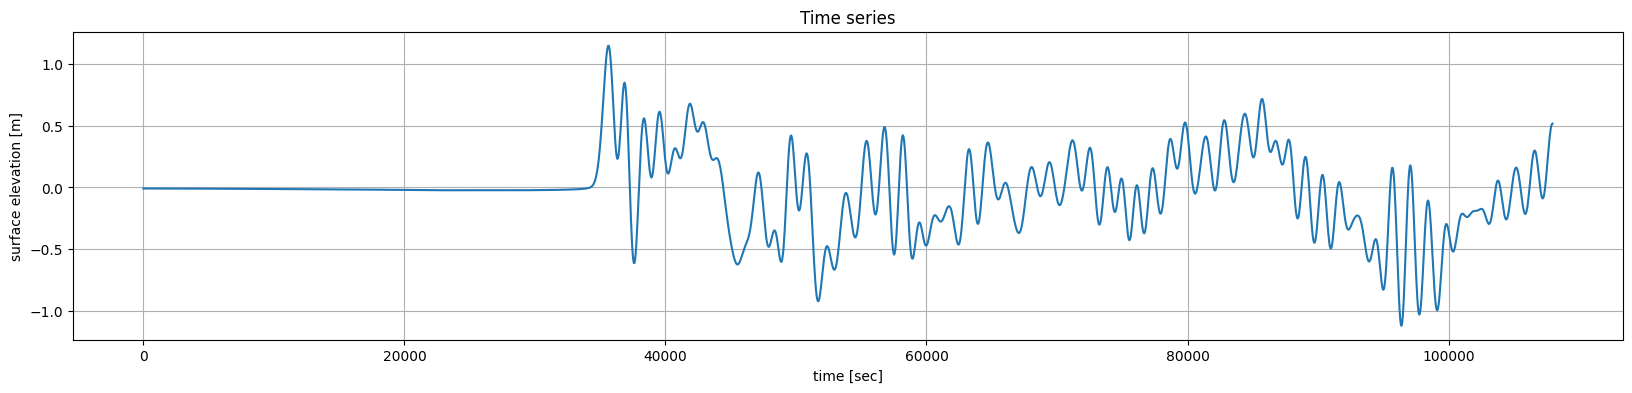

In [7]:
#inspect a plot for chosen time serie
import matplotlib.pyplot as plt
import numpy as np  
data=np.loadtxt(tmsf)
plt.figure(figsize=(20,4))
plt.plot(data[:,0],data[:,1])   
plt.xlabel('time [sec]')
plt.ylabel('surface elevation [m]')
plt.title('Time series')
plt.grid()
plt.show()

In [ ]:
#read amplification factors
af=readAF("../ampfactors/global_ampf_v04.txt")

In [ ]:
# calculate MIH for the chosen time series
ampfact_id="id03700"

plot=True
plot_dir="plot"
plot_name="plot_tms_"+tmsf.split("/")[-1].split(".")[0]+"_"+ampfact_id
results=tms(tmsf, af, ampfact_id, plot, plot_dir, plot_name,tsample=5)   

Prosessing mariogram from example_general/tms_00501.txt

Inspect plot: plot/plot_tms_tms_00501_id03700_eta.png
MIH for mariogram example_general/tms_00501.txt is 3.8 m with offshore wave amplitude of 1.1 m, wave period 1339 s and amplification factor 3.27.


<Figure size 640x480 with 0 Axes>

In [ ]:
#calculate MIH from HySEA output
#run postprocessing script to extract wave parameters for all the time series and save them in a txt file (wave periode, max wave height, amplification factor, MIH)
#import subprocess
#subprocess.run(["wsl","../postprocess_HySEA/postprocess_HySea", "example_HySEA/result_ts.nc"], check=True)
import os
os.system("../postprocess_HySEA/postprocess_HySea example_HySEA/result_ts.nc")
#this command will creat a the file first 10 lines shown below, 
print("".join(open("example_HySEA/result_ts.nc.offshore.txt").readlines()[:10]))

ID lon lat depth max_ssh min_ssh period polarity return_code
    1	+120.8333	+18.6672	 47	0.121	-0.155	 1357	 1	3
    2	+120.8721	+18.6333	-54	54.499	54.499	    0	 0	1
    3	+120.9333	+18.5795	123	0.149	-0.212	 1868	 1	3
    4	+121.0000	+18.6215	199	0.154	-0.183	 1197	 1	3
    5	+121.0667	+18.6484	105	0.221	-0.194	 1308	 1	3
    6	+121.1667	+18.6492	 91	0.276	-0.262	 2367	 1	3
    7	+121.2333	+18.6119	 50	0.293	-0.308	 2055	 1	3
    8	+121.2878	+18.5667	 26	0.503	-0.342	 2243	-1	3
    9	+121.3347	+18.5333	 10	0.594	-0.478	 2261	 1	3

